# Полное дообучение модели XLS-R 300m

__Описание:__ дообучение всех слоёв нейронной сети, включая все слои XLS-R и собственные верхние слои. Обучение слоёв XLS-R будет осуществляться с более низким значением learning_rate

## 1. Загрузка данных

In [1]:
import os
import random
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve
from IPython.display import clear_output

import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Model, Wav2Vec2Config
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss

In [2]:
DATASET_PATH = "./russian_sdd_dataset"
SR = 16_000
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device set to use: {DEVICE}")

Device set to use: cuda


In [3]:
df = pd.read_csv(DATASET_PATH + '/train.csv', index_col=0)
df.head(3)

,audio,tts_model,audio_filter,gender,label,spk_id
0,real/000001.wav,NaN,True,male,0,0
1,fake/000001.wav,F5-TTS,True,male,1,0
2,real/000002.wav,NaN,True,male,0,0


In [4]:
def speaker_independent_split(df: pd.DataFrame, val_ratio: float = 0.15) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not 0 <= val_ratio <= 1:
        raise ValueError(f"Invalid val_ratio: {val_ratio}")
        
    df_ = df.copy()
    unique_speakers = df_['spk_id'].unique()

    train_speakers = set(unique_speakers[:int(len(unique_speakers)*(1-val_ratio))])
    val_speakers = set(unique_speakers[int(len(unique_speakers)*(1-val_ratio)): ])

    df_['split'] = df_['spk_id'].apply(lambda x: "train" if x in train_speakers else "val")

    train_df = df_[df_['split'] == "train"]
    val_df = df_[df_['split'] == "val"]

    return train_df, val_df 

In [5]:
def load_audio(audio_path: str) -> torch.Tensor:
    sample_rate = 16_000
    
    wav, sr = torchaudio.load(audio_path)
        
    if sr != sample_rate:
        wav = torchaudio.transforms.Resample(sr, sample_rate)(wav)
            
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
            
    return wav

In [6]:
train_df, val_df = speaker_independent_split(df, val_ratio = 0.15)

train_paths = [os.path.join(DATASET_PATH, audio) for audio in train_df['audio']]
val_paths = [os.path.join(DATASET_PATH, audio) for audio in val_df['audio']]

train_audios = [load_audio(audio) for audio in tqdm(train_paths)]
val_audios = [load_audio(audio) for audio in tqdm(val_paths)]

train_labels = train_df['label'].tolist()
val_labels = val_df['label'].tolist()

  0%|          | 0/11208 [00:00<?, ?it/s]

  0%|          | 0/1992 [00:00<?, ?it/s]

In [7]:
class RSDDDataset(Dataset):
    def __init__(self, 
                 audios: list[torch.Tensor], 
                 labels: list[int], 
                 mode: str, 
                 sample_rate: int = 16_000, 
                 duration: float = 3.0,
                 rir_folder: str | None = None,
                 rir_proba: float = 0.5):
        """
        :param audios: Список путей к аудиофайлам.
        :param labels: Список меток (0/1).
        :param mode: 'train' или 'val'.
        :param sample_rate: Целевая частота дискретизации.
        :param duration: Длительность сегмента в секундах.
        :param rir_folder: Путь к папке с импульсными откликами (для аугментаций)
        :param rir_proba: Вероятность, с которой к аудио будет применена RIR аугментация
        """
        if mode not in {"train", "val"}:
            raise ValueError(f"Invalid mode: {mode}")
            
        self.audios = audios
        self.labels = labels 
        self.mode = mode  
        self.sample_rate = sample_rate
        self.duration = duration
        self.n_samples = int(sample_rate * duration)
        
        self.rirs = []
        self.rir_proba = rir_proba
        if mode == "train" and rir_folder is not None:
            if not os.path.exists(rir_folder):
                raise ValueError(f"Rir folder does not exist: {rir_folder}")
            self._load_rirs(rir_folder)

    
    def __len__(self):
        return len(self.audios)

    
    def _load_rirs(self, folder: str):
        """Загружает и предобрабатывает импульсные отклики."""            
        files = os.listdir(folder)
        files = [os.path.join(folder, rir_file) for rir_file in files]
        for rir_file in files:
            rir, rir_sr = torchaudio.load(rir_file)
            if rir_sr != self.sample_rate:
                rir = torchaudio.transforms.Resample(rir_sr, self.sample_rate)(rir)
            self.rirs.append(rir)
        

    
    def _load_audio(self, audio_path: str) -> torch.Tensor:
        wav, sr = torchaudio.load(audio_path)
        
        if sr != self.sample_rate:
            wav = torchaudio.transforms.Resample(sr, self.sample_rate)(wav)
            
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
            
        return wav

    
    def _apply_rir(self, wav: torch.Tensor, rir: torch.Tensor):
        """Применяет реверберацию к аудио (симуляция среды)"""
        left_pad = right_pad = rir.shape[-1] - 1
        
        flipped_rir = rir.squeeze().flip(0)
    
        wav = F.pad(wav, [left_pad, right_pad]).view(1, 1, -1)
        wav = torch.conv1d(wav, flipped_rir.view(1, 1, -1)).squeeze()
        
        if wav.abs().max() > 1:
            wav /= wav.abs().max()

        return wav.unsqueeze(0)

    def _apply_rir_fft(self, wav: torch.Tensor, rir: torch.Tensor) -> torch.Tensor:
        """Применяет реверберацию через частотную область (быстрее для длинных RIR)"""
        # Убираем канал, работаем с 1D
        wav_1d = wav.squeeze(0)
        rir_1d = rir.squeeze()
        
        # FFT-свёртка через torch.fft
        wav_fft = torch.fft.rfft(wav_1d, n=wav_1d.shape[-1] + rir_1d.shape[-1] - 1)
        rir_fft = torch.fft.rfft(rir_1d, n=wav_1d.shape[-1] + rir_1d.shape[-1] - 1)
        conv_fft = wav_fft * rir_fft
        convolved = torch.fft.irfft(conv_fft, n=wav_1d.shape[-1] + rir_1d.shape[-1] - 1)
        
        # Обрезаем до исходной длины + паддинга
        valid_length = wav_1d.shape[-1] + rir_1d.shape[-1] - 1
        convolved = convolved[:valid_length]
        
        # Нормализация
        if convolved.abs().max() > 1:
            convolved = convolved / convolved.abs().max()
        
        return convolved.unsqueeze(0)

    
    def _audio_loop(self, wav: torch.Tensor) -> torch.Tensor:
        """Зацикливает аудио, если оно короче нужной длины"""
        n_repeat = self.n_samples // wav.shape[-1] + 1
        wav = wav.repeat(1, n_repeat)
        wav = wav[:, :self.n_samples]
        return wav


    def _process_train(self, wav: torch.Tensor) -> torch.Tensor:
        if self.rirs and random.random() >= self.rir_proba:
            rir = random.choice(self.rirs)
            wav = self._apply_rir_fft(wav, rir)
            
        if wav.shape[-1] > self.n_samples:
            max_index = wav.shape[-1] - self.n_samples
            start_index = random.randint(0, max_index)
            end_index = start_index + self.n_samples 
            wav = wav[:, start_index:end_index]
        else:
            wav = self._audio_loop(wav)
            
        return wav 


    def _process_val(self, wav: torch.Tensor) -> torch.Tensor:
        if wav.shape[-1] >= self.n_samples:
            return wav[:, :self.n_samples]
        else:
            return self._audio_loop(wav)

    
    def __getitem__(self, idx):
        wav = self.audios[idx]
        label = self.labels[idx]

        #wav = self._load_audio(audio_path)

        if self.mode == "train":
            wav = self._process_train(wav)
        else:
            wav = self._process_val(wav)
            
        wav = wav.float()
        
        return wav, torch.tensor(label, dtype=torch.float32)

In [8]:
BATCH_SIZE = 32

In [9]:
train_dataset = RSDDDataset(train_audios, train_labels, mode='train', rir_folder='./rir-data', rir_proba=0.5, duration=5.0)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=True, pin_memory=True, persistent_workers=True)

val_dataset = RSDDDataset(val_audios, val_labels, mode='val', duration=5.0)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=False, pin_memory=True, persistent_workers=True)

## 2. Архитектура модели

In [10]:
class Wav2Vec2FeatureExtractor(nn.Module):
    def __init__(self, model_config: str | None = None, model_path: str | None = "facebook/wav2vec2-xls-r-300m"):
        """
        Параметры:
            * model_config - путь до json-файла с конфигурацией модели. Если не None, то будет загружена необученная модель.
            * model_path - путь до весов модели. По умолчанию загружается предобученная модель с HF.
        """
        super().__init__()
        
        if model_config:
            config = Wav2Vec2Config.from_json_file(model_config)
            self.model = Wav2Vec2Model(config)
        else:
            self.model = Wav2Vec2Model.from_pretrained(model_path)
            
        self.hidden_size = self.model.config.hidden_size 
        self.num_layers = self.model.config.num_hidden_layers

        
    def forward(self, waveforms: torch.Tensor) -> tuple[torch.Tensor, list[torch.Tensor]]:
        """
        Возвращает:
            * features [batch_size, self.num_layers, 2*self.hidden_size] - статистические векторы для каждого слоя
        """
        # убираем размерность канала за ненадобностью 
        if waveforms.dim() == 3 and waveforms.shape[1] == 1:
            waveforms = waveforms.squeeze(1)
            
        outputs = self.model(
            input_values=waveforms,
            output_hidden_states=True
        )
        
        # первый элемент - это выход CNN энкодера, его мы пропустим
        layer_outputs = outputs.hidden_states[1:]  
        layer_outputs = torch.stack(layer_outputs, dim=1)

        mean_pooled = layer_outputs.mean(dim=2)
        std_pooled = layer_outputs.mean(dim=2)

        features = torch.cat([mean_pooled, std_pooled], dim=-1)
        
        return features

In [11]:
class LayerAttentionPool(nn.Module):
    def __init__(self, features_dim: int, hidden_dim: int = 256):
        super().__init__()
        
        self.layer_attention = nn.Sequential(
            nn.LayerNorm(features_dim),
            nn.Linear(features_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        
    def forward(self, features: torch.Tensor) -> torch.Tensor:
        weights = self.layer_attention(features)
        aggregated = (features * weights).sum(dim=1)
        return aggregated

In [12]:
class Wav2Vec2DeepfakeDetector(nn.Module):
    def __init__(self, 
                 ssl_model_config: str | None = None,
                 ssl_model_from_pretrained: str = "facebook/wav2vec2-xls-r-300m", 
                 attention_dim: int = 256, hidden_dim: int = 256, dropout: float = 0.3):
        super().__init__()

        if ssl_model_config:
            self.feature_extractor = Wav2Vec2FeatureExtractor(model_config=ssl_model_config)
        else:
            self.feature_extractor = Wav2Vec2FeatureExtractor(model_path=ssl_model_from_pretrained)
        features_dim = self.feature_extractor.hidden_size * 2
        
        self.layer_aggregator = LayerAttentionPool(features_dim=features_dim, hidden_dim=attention_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(features_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1)
        )

        self._init_weights(self.layer_aggregator)
        self._init_weights(self.classifier)

        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            init.normal_(module.weight, mean=0.0, std=1.0)
            if module.bias is not None:
                init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            init.ones_(module.weight)
            init.zeros_(module.bias)

    
    def forward(self, wavs: torch.Tensor):
        features = self.feature_extractor(wavs)
        aggregated = self.layer_aggregator(features)
        logits = self.classifier(self.dropout(aggregated))
        return logits

In [13]:
from torchinfo import summary


model = Wav2Vec2DeepfakeDetector(
    ssl_model_from_pretrained = "facebook/wav2vec2-xls-r-300m",
    attention_dim = 256, 
    hidden_dim = 256).to(DEVICE)

summary(model)

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Layer (type:depth-idx)                                                 Param #
Wav2Vec2DeepfakeDetector                                               --
├─Wav2Vec2FeatureExtractor: 1-1                                        --
│    └─Wav2Vec2Model: 2-1                                              1,024
│    │    └─Wav2Vec2FeatureEncoder: 3-1                                4,210,176
│    │    └─Wav2Vec2FeatureProjection: 3-2                             526,336
│    │    └─Wav2Vec2EncoderStableLayerNorm: 3-3                        310,701,184
├─LayerAttentionPool: 1-2                                              --
│    └─Sequential: 2-2                                                 --
│    │    └─LayerNorm: 3-4                                             4,096
│    │    └─Linear: 3-5                                                524,544
│    │    └─GELU: 3-6                                                  --
│    │    └─Linear: 3-7                                                257


## 3. Обучение

In [14]:
def calculate_eer(y_true, y_probas):
    """Рассчитывает EER и соответствующий порог"""
    fpr, tpr, thresholds = roc_curve(y_true, y_probas, pos_label=1)
    
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    thresh = interp1d(fpr, thresholds)(eer)
    
    return fpr, tpr, thresholds, eer, thresh

In [15]:
@dataclass
class Metrics:
    train_loss: list[float] = field(default_factory=list)
    val_loss: list[float] = field(default_factory=list)
    val_eer: list[float] = field(default_factory=list)


def plot_metrics(metrics: Metrics):
    clear_output(True)
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    axes[0].set_title("Train Loss")
    axes[0].plot(range(len(metrics.train_loss)), metrics.train_loss, color='blue')
    axes[0].grid()
    
    axes[1].set_title("Val EER")
    axes[1].plot(range(len(metrics.val_eer)), metrics.val_eer, color='red')
    axes[1].grid()
    plt.show()
    
    

def evaluate(model, loss_fn, val_dataloader):
    model.eval()
    total_loss = 0.0
    batch_cntr = 0
    predictions = []
    true_labels = []
    
    device = DEVICE
    
    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc=f"Validation", leave=False):
            inputs, targets = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, targets)
            
            total_loss += loss.item()
            
            predictions.extend(outputs.cpu().numpy())
            true_labels.extend(targets.cpu().numpy())

            batch_cntr += 1
            
    avg_loss = total_loss / batch_cntr
    _, _, _, eer, _ = calculate_eer(np.array(true_labels), np.array(predictions))
    
    return avg_loss, eer
    

def train(model, optimizer, loss_fn, train_dataloader, val_dataloader, n_epochs=20, checkpoint_path = "./best_model.pt", log_step=50):
    metrics = Metrics()
    best_eer = 1.0 
    best_train_loss = 10**10
    best_val_loss = 10**10
    early_stopping_cntr = 0

    for epoch in tqdm(range(n_epochs)):
        step = 0
        current_loss = 0.0
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch}: training", leave=False):
            model.train()
            inputs, targets = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, targets)
            
            loss.backward()
            optimizer.step()

            step += 1
            current_loss += loss.item()

            if step % log_step == 0:
                train_loss = current_loss / log_step
                current_loss = 0.0
                val_loss, val_eer = evaluate(model, loss_fn, val_dataloader) 
                metrics.train_loss.append(train_loss)
                metrics.val_loss.append(val_loss)
                metrics.val_eer.append(val_eer)

                if val_eer < best_eer:
                    best_eer = val_eer 
                    if checkpoint_path:
                        torch.save({'model_state_dict': model.state_dict()}, checkpoint_path)
            
                best_train_loss = min(best_train_loss, train_loss)
                best_val_loss = min(best_val_loss, val_loss)

                plot_metrics(metrics)
                print(f"Current train loss: {train_loss}  |  Best: {best_train_loss}")
                print(f"Current validation loss: {val_loss}  |  Best: {best_val_loss}")
                print(f"Current validation EER: {val_eer}  |  Best EER: {best_eer}")
            
    return metrics

In [16]:
optimizer = AdamW([
    {"params": model.feature_extractor.parameters(), "lr": 0.00005},
    {"params": model.layer_aggregator.parameters(), "lr": 0.0005},
    {"params": model.classifier.parameters(), "lr": 0.0005}
])
loss_fn = BCEWithLogitsLoss()

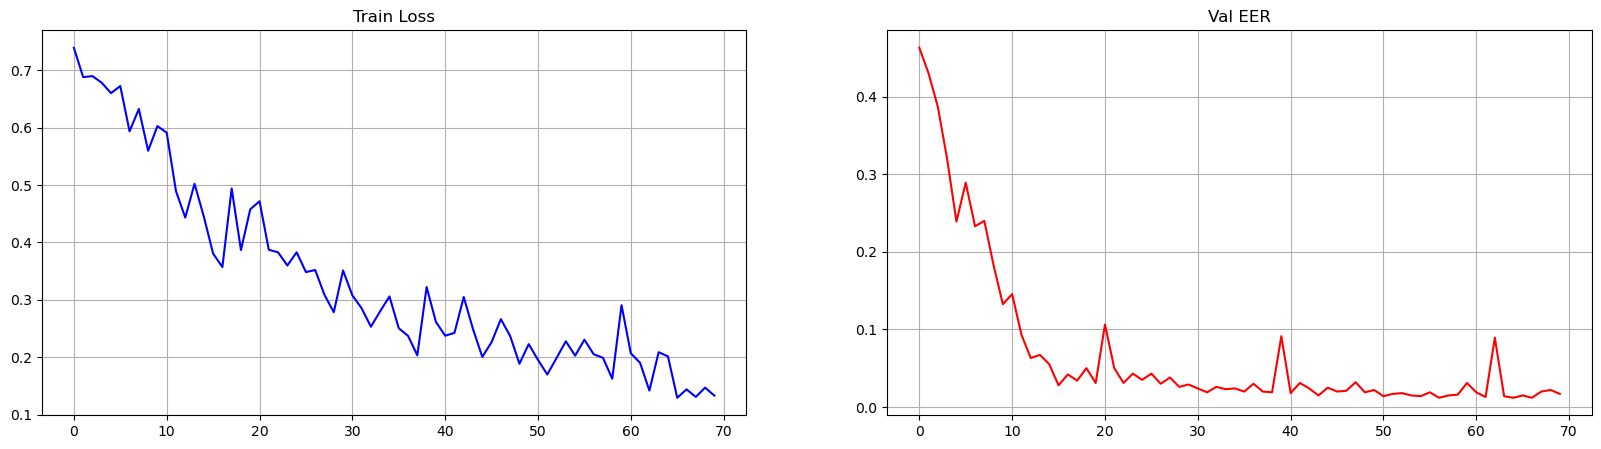

Current train loss: 0.1330375611782074  |  Best: 0.12930447317659854
Current validation loss: 0.566917356125833  |  Best: 0.06456214750540398
Current validation EER: 0.017068273092369413  |  Best EER: 0.012048192771084409


In [17]:
metrics = train(
    model, 
    optimizer, 
    loss_fn, 
    train_dataloader, 
    val_dataloader,
    n_epochs=5,
    log_step=25)

In [18]:
metrics_df = pd.DataFrame()

metrics_df['train_loss'] = metrics.train_loss
metrics_df['val_loss'] = metrics.val_loss
metrics_df['val_eer'] = metrics.val_eer

metrics_df.to_csv("xlsr_train_metrics.csv")